In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

sns.set(style="whitegrid")
pd.set_option("display.max_columns", None)

DATA_PATH = Path("../notebooks/transactions-2025-03-21/transactions-2025-03-21.csv")
df = pd.read_csv(DATA_PATH)
df_original = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
df.head()


Shape: (53481, 22)


,TRANSACTION_NUMBER,INSTANCE_DATE,GROUP_EN,PROCEDURE_EN,IS_OFFPLAN_EN,IS_FREE_HOLD_EN,USAGE_EN,AREA_EN,PROP_TYPE_EN,PROP_SB_TYPE_EN,TRANS_VALUE,PROCEDURE_AREA,ACTUAL_AREA,ROOMS_EN,PARKING,NEAREST_METRO_EN,NEAREST_MALL_EN,NEAREST_LANDMARK_EN,TOTAL_BUYER,TOTAL_SELLER,MASTER_PROJECT_EN,PROJECT_EN
0,101-1-2025,2025-02-06 09:46:41,Mortgage,Portfolio Mortgage Registration Pre-Registration,Off-Plan,Free Hold,Residential,JUMEIRAH VILLAGE CIRCLE,Unit,Hotel Apartment,1600000.0,160.62,160.62,2 B/R,1,Dubai Internet City,Marina Mall,Sports City Swimming Academy,0,0,NaN,NORTH FORTY THREE SERVICED RESIDENCES
1,101-1-2025,2025-02-06 09:46:41,Mortgage,Portfolio Mortgage Registration Pre-Registration,Off-Plan,Free Hold,Residential,JUMEIRAH VILLAGE CIRCLE,Unit,Hotel Apartment,1600000.0,172.26,172.26,3 B/R,1,Dubai Internet City,Marina Mall,Sports City Swimming Academy,0,0,NaN,NORTH FORTY THREE SERVICED RESIDENCES
2,101-1-2025,2025-02-06 09:46:41,Mortgage,Portfolio Mortgage Registration Pre-Registration,Off-Plan,Free Hold,Residential,JUMEIRAH VILLAGE CIRCLE,Unit,Hotel Apartment,1600000.0,140.05,140.05,3 B/R,1,Dubai Internet City,Marina Mall,Sports City Swimming Academy,0,0,NaN,NORTH FORTY THREE SERVICED RESIDENCES
3,101-1-2025,2025-02-06 09:46:41,Mortgage,Portfolio Mortgage Registration Pre-Registration,Off-Plan,Free Hold,Residential,JUMEIRAH VILLAGE CIRCLE,Unit,Hotel Apartment,1600000.0,170.68,170.68,2 B/R,1,Dubai Internet City,Marina Mall,Sports City Swimming Academy,0,0,NaN,NORTH FORTY THREE SERVICED RESIDENCES
4,101-1-2025,2025-02-06 09:46:41,Mortgage,Portfolio Mortgage Registration Pre-Registration,Off-Plan,Free Hold,Residential,JUMEIRAH VILLAGE CIRCLE,Unit,Hotel Apartment,1600000.0,117.58,117.58,3 B/R,1,Dubai Internet City,Marina Mall,Sports City Swimming Academy,0,0,NaN,NORTH FORTY THREE SERVICED RESIDENCES


# Dataset overview: size, date range, transaction distribution

## Size

In [2]:
print("Dataset shape is :", df.shape)
print("\nColumns:\n", df.columns.tolist())

Dataset shape is : (53481, 22)

Columns:
 ['TRANSACTION_NUMBER', 'INSTANCE_DATE', 'GROUP_EN', 'PROCEDURE_EN', 'IS_OFFPLAN_EN', 'IS_FREE_HOLD_EN', 'USAGE_EN', 'AREA_EN', 'PROP_TYPE_EN', 'PROP_SB_TYPE_EN', 'TRANS_VALUE', 'PROCEDURE_AREA', 'ACTUAL_AREA', 'ROOMS_EN', 'PARKING', 'NEAREST_METRO_EN', 'NEAREST_MALL_EN', 'NEAREST_LANDMARK_EN', 'TOTAL_BUYER', 'TOTAL_SELLER', 'MASTER_PROJECT_EN', 'PROJECT_EN']


## Date range, transaction distribution

In [3]:
df["INSTANCE_DATE"] = pd.to_datetime(df["INSTANCE_DATE"], errors="coerce")

print("Date range:")
print("Start:", df["INSTANCE_DATE"].min())
print("End:", df["INSTANCE_DATE"].max())


Date range:
Start: 2025-01-01 21:47:23
End: 2025-03-21 11:44:59


## Transaction distribution with respect to time, other type of transaction distribution given further down

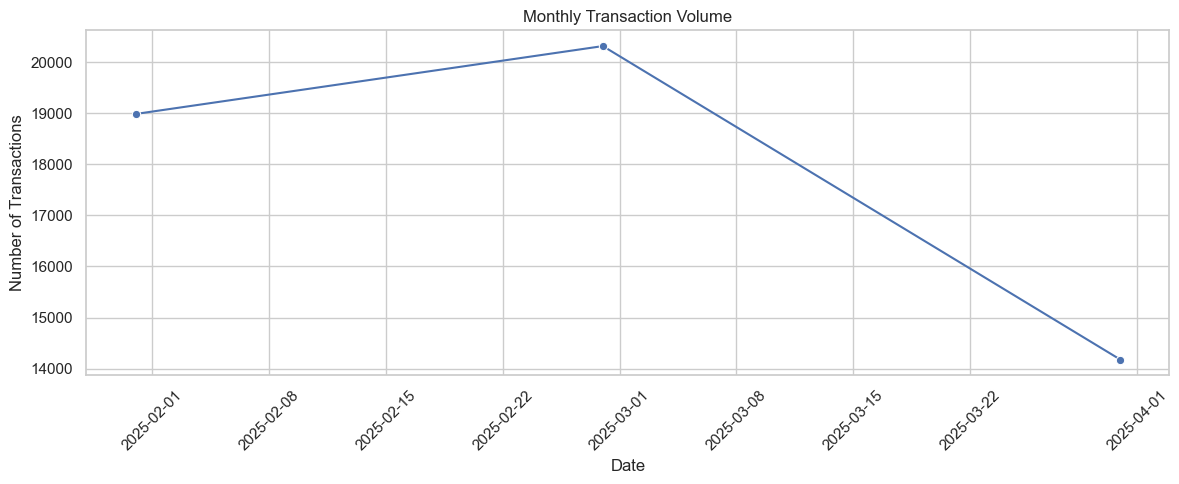

In [4]:
monthly_counts = (
    df.set_index("INSTANCE_DATE")["TRANS_VALUE"]
      .resample("ME")
      .count()
      .rename("transaction_count")
      .reset_index()
)

plt.figure(figsize=(12,5))
sns.lineplot(
    data=monthly_counts,
    x="INSTANCE_DATE",
    y="transaction_count",
    marker="o"
)

plt.title("Monthly Transaction Volume")
plt.xlabel("Date")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# Missing Values & Data Quality

## Missing Values

In [5]:
missing = df.isnull().sum()
missing_percent = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    "missing_count": missing,
    "missing_percent": missing_percent
}).sort_values("missing_percent", ascending=False)

missing_df[missing_df["missing_count"] > 0]


,missing_count,missing_percent
MASTER_PROJECT_EN,53382,99.814888
NEAREST_MALL_EN,25085,46.904508
NEAREST_METRO_EN,24665,46.119183
NEAREST_LANDMARK_EN,18553,34.690825
PARKING,15746,29.442232
ROOMS_EN,10023,18.741235
PROJECT_EN,7955,14.874441
PROP_SB_TYPE_EN,2372,4.435220


# Let's check for duplicacy 

In [6]:
int(df["TRANSACTION_NUMBER"].duplicated().sum())

1920

In [7]:
df[df["TRANSACTION_NUMBER"].duplicated() == True].head(1)

,TRANSACTION_NUMBER,INSTANCE_DATE,GROUP_EN,PROCEDURE_EN,IS_OFFPLAN_EN,IS_FREE_HOLD_EN,USAGE_EN,AREA_EN,PROP_TYPE_EN,PROP_SB_TYPE_EN,TRANS_VALUE,PROCEDURE_AREA,ACTUAL_AREA,ROOMS_EN,PARKING,NEAREST_METRO_EN,NEAREST_MALL_EN,NEAREST_LANDMARK_EN,TOTAL_BUYER,TOTAL_SELLER,MASTER_PROJECT_EN,PROJECT_EN
1,101-1-2025,2025-02-06 09:46:41,Mortgage,Portfolio Mortgage Registration Pre-Registration,Off-Plan,Free Hold,Residential,JUMEIRAH VILLAGE CIRCLE,Unit,Hotel Apartment,1600000.0,172.26,172.26,3 B/R,1,Dubai Internet City,Marina Mall,Sports City Swimming Academy,0,0,NaN,NORTH FORTY THREE SERVICED RESIDENCES


In [8]:
df[df["TRANSACTION_NUMBER"]== '101-1-2025'].head(3)

,TRANSACTION_NUMBER,INSTANCE_DATE,GROUP_EN,PROCEDURE_EN,IS_OFFPLAN_EN,IS_FREE_HOLD_EN,USAGE_EN,AREA_EN,PROP_TYPE_EN,PROP_SB_TYPE_EN,TRANS_VALUE,PROCEDURE_AREA,ACTUAL_AREA,ROOMS_EN,PARKING,NEAREST_METRO_EN,NEAREST_MALL_EN,NEAREST_LANDMARK_EN,TOTAL_BUYER,TOTAL_SELLER,MASTER_PROJECT_EN,PROJECT_EN
0,101-1-2025,2025-02-06 09:46:41,Mortgage,Portfolio Mortgage Registration Pre-Registration,Off-Plan,Free Hold,Residential,JUMEIRAH VILLAGE CIRCLE,Unit,Hotel Apartment,1600000.0,160.62,160.62,2 B/R,1,Dubai Internet City,Marina Mall,Sports City Swimming Academy,0,0,NaN,NORTH FORTY THREE SERVICED RESIDENCES
1,101-1-2025,2025-02-06 09:46:41,Mortgage,Portfolio Mortgage Registration Pre-Registration,Off-Plan,Free Hold,Residential,JUMEIRAH VILLAGE CIRCLE,Unit,Hotel Apartment,1600000.0,172.26,172.26,3 B/R,1,Dubai Internet City,Marina Mall,Sports City Swimming Academy,0,0,NaN,NORTH FORTY THREE SERVICED RESIDENCES
2,101-1-2025,2025-02-06 09:46:41,Mortgage,Portfolio Mortgage Registration Pre-Registration,Off-Plan,Free Hold,Residential,JUMEIRAH VILLAGE CIRCLE,Unit,Hotel Apartment,1600000.0,140.05,140.05,3 B/R,1,Dubai Internet City,Marina Mall,Sports City Swimming Academy,0,0,NaN,NORTH FORTY THREE SERVICED RESIDENCES


### It is stated that transaction number is unique, however we see that many datapoints exist with same transaction number and they have different ROOMS_EN and ACTUAL_AREA and PROCEDURE_AREA. We will proceed with the assumption that these datapoints belong to same transaction with multiple properties bought together

## Let's analyse missing categories

In [9]:
missing = df.isnull().sum()
missing_percent = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    "missing_count": missing,
    "missing_percent": missing_percent
}).sort_values("missing_percent", ascending=False)

missing_df[missing_df["missing_count"] > 0]


,missing_count,missing_percent
MASTER_PROJECT_EN,53382,99.814888
NEAREST_MALL_EN,25085,46.904508
NEAREST_METRO_EN,24665,46.119183
NEAREST_LANDMARK_EN,18553,34.690825
PARKING,15746,29.442232
ROOMS_EN,10023,18.741235
PROJECT_EN,7955,14.874441
PROP_SB_TYPE_EN,2372,4.435220


### Let's analyse category MASTER_PROJECT_EN

In [10]:
print(df["MASTER_PROJECT_EN"].value_counts())
print(f"\n total count of these:{int(df["MASTER_PROJECT_EN"].value_counts().sum())}\n")


MASTER_PROJECT_EN
Elysee Heights                           46
Jebel Ali Village Townhouses- Phase 1    22
Remraam - Al Ramth                       14
JANNAT                                   10
Palace Beach Residence                    6
Hills Park                                1
Name: count, dtype: int64

 total count of these:99



### 99 datapoints in 53481 with available MASTER_PROJECT_EN, doesn't make sense to iuse it, let's drop it

In [11]:
df.drop(columns=["MASTER_PROJECT_EN"], inplace=True)


### Let's analyse category NEAREST_MALL_EN, NEAREST_METRO_EN, NEAREST_LANDMARK_EN

In [12]:
print(df["NEAREST_MALL_EN"].value_counts())
print(f"\n total count of these:{int(df["NEAREST_MALL_EN"].value_counts().sum())}\n")


NEAREST_MALL_EN
Marina Mall             10266
Dubai Mall               7221
Mall of the Emirates     5526
Ibn-e-Battuta Mall       3193
City Centre Mirdif       2190
Name: count, dtype: int64

 total count of these:28396



In [13]:
print(df["NEAREST_METRO_EN"].value_counts())
print(f"\n total count of these:{int(df["NEAREST_METRO_EN"].value_counts().sum())}\n")


NEAREST_METRO_EN
Dubai Internet City                     3349
Buj Khalifa Dubai Mall Metro Station    2962
Nakheel Metro Station                   2874
Business Bay Metro Station              2570
Damac Properties                        1800
Sharaf Dg Metro Station                 1652
First Abu Dhabi Bank Metro Station      1426
Jumeirah Lakes Towers                   1396
Rashidiya Metro Station                 1251
Creek Metro Station                      994
UAE Exchange Metro Station               976
Ibn Battuta Metro Station                889
Harbour Tower                            734
Marina Towers                            658
Jumeirah Beach Residency                 531
Marina Mall Metro Station                525
ENERGY Metro Station                     461
Mina Seyahi                              441
Palm Jumeirah                            410
Jumeirah Beach Resdency                  403
Al Jadaf Metro Station                   319
Dubai Marina                          

In [14]:
print(df["NEAREST_LANDMARK_EN"].value_counts())
print(f"\n total count of these:{int(df["NEAREST_LANDMARK_EN"].value_counts().sum())}\n")


NEAREST_LANDMARK_EN
Sports City Swimming Academy         9480
Downtown Dubai                       5007
IMG World Adventures                 4385
Burj Al Arab                         4354
Motor City                           3622
Expo 2020 Site                       2487
Burj Khalifa                         1788
Dubai International Airport          1725
Dubai Cycling Course                  917
Global Village                        480
Hamdan Sports Complex                 268
Al Makhtoum International Airport     261
Dubai Parks and Resorts               151
Jabel Ali                               3
Name: count, dtype: int64

 total count of these:34928



### they seem important with regards to selecting a proprty and we shouldn't drop them and rather fill the missing values with unknkown

In [15]:
location_cols = [
    "NEAREST_MALL_EN",
    "NEAREST_METRO_EN",
    "NEAREST_LANDMARK_EN"
]

for col in location_cols:
    df[col] = df[col].fillna("Unknown")


### Let's analyse category PARKING

In [16]:
print(df["PARKING"].value_counts())
print(f"\n total count of these:{int(df["PARKING"].value_counts().sum())}\n")


PARKING
1           18053
2            1359
1  0          281
EU            276
3              87
            ...  
14 3B 01        1
8-G-13          1
14GB25          1
14GA24          1
14 2B 24        1
Name: count, Length: 7825, dtype: int64

 total count of these:37735



### PARKING category is not numerical value completely, rather alphanumeric, we will keep numerical values only and set the other values as 0, we could also see that 14 2B 24  might mean one parking slot address and it could be 1, but that might add noise and so we will still keep those values as 0

In [17]:
df["PARKING"] = df["PARKING"].astype(str)

# Keep only fully numeric entries
df["PARKING_CLEAN"] = np.where(
    df["PARKING"].str.fullmatch(r"\d+"),
    df["PARKING"],
    np.nan
)

df["PARKING_CLEAN"] = pd.to_numeric(df["PARKING_CLEAN"], errors="coerce")

# Missing flag
df["parking_missing"] = df["PARKING_CLEAN"].isnull().astype(int)

# Fill missing with 0
df["PARKING_CLEAN"] = df["PARKING_CLEAN"].fillna(0).astype(int)

df.drop(columns=["PARKING"], inplace=True)
df.rename(columns={"PARKING_CLEAN": "PARKING"}, inplace=True)


### Let's analyse category ROOMS_EN

In [18]:
print(df["ROOMS_EN"].value_counts())
print(f"\n total count of these:{int(df["ROOMS_EN"].value_counts().sum())}\n")


ROOMS_EN
1 B/R        15592
2 B/R        10611
Studio        8022
3 B/R         5538
4 B/R         2328
Office         892
Shop           216
5 B/R          197
PENTHOUSE       41
6 B/R           13
7 B/R            4
GYM              4
Name: count, dtype: int64

 total count of these:43458



we can categorise them as residential and if they are residential we keep the number of rooms  

In [19]:
df["ROOMS_EN"] = df["ROOMS_EN"].astype(str).str.strip()
df["BEDROOMS"] = df["ROOMS_EN"].str.extract(r"(\d+)")
df["BEDROOMS"] = pd.to_numeric(df["BEDROOMS"], errors="coerce")
df.loc[df["ROOMS_EN"].str.contains("Studio", case=False, na=False), "BEDROOMS"] = 1
df["ROOM_TYPE"] = np.where(
    df["ROOMS_EN"].str.contains("Office|Shop|GYM|PENTHOUSE", case=False, na=False),
    df["ROOMS_EN"],
    "Residential"
)
df["BEDROOMS"] = df["BEDROOMS"].fillna(0)


In [20]:
print(df["BEDROOMS"].value_counts())
print(f"\n total count of these:{int(df["BEDROOMS"].value_counts().sum())}\n")



BEDROOMS
1.0    23614
0.0    11176
2.0    10611
3.0     5538
4.0     2328
5.0      197
6.0       13
7.0        4
Name: count, dtype: int64

 total count of these:53481



### Let's analyse category PROJECT_EN

In [21]:
print(df["PROJECT_EN"].value_counts())
print(f"\n total count of these:{int(df["PROJECT_EN"].value_counts().sum())}\n")


PROJECT_EN
Terra Heights                    731
DAMAC ISLANDS - BORA BORA 3      427
DAMAC HILLS (2) - VIOLET 3       406
The Valley - Farm Grove          385
La Tilia at Villanova Phase 2    383
                                ... 
SONDOS ORCHID                      1
SONDOS LILY                        1
SONDOS ROSA                        1
CLUB VILLAS                        1
EQUITI TOWER                       1
Name: count, Length: 2115, dtype: int64

 total count of these:45526



let's fill na with unknown

In [22]:
df['PROJECT_EN'] = df['PROJECT_EN'].fillna("Unknown")

### Let's analyse category PROP_SB_TYPE_EN

In [23]:
print(df["PROP_SB_TYPE_EN"].value_counts())
print(f"\n total count of these:{int(df["PROP_SB_TYPE_EN"].value_counts().sum())}\n")


PROP_SB_TYPE_EN
Flat                                                  36010
Villa                                                  5457
Residential                                            4146
Commercial                                             1546
Office                                                 1275
Hotel Apartment                                         681
Shop                                                    549
Land                                                    412
Hotel Rooms                                             338
Government Housing                                      258
Residential Flats                                        81
Residential / Attached Villas                            66
Airport                                                  62
Industrial                                               58
General Use                                              55
Unit                                                     26
Sports Club             

let's fill na with unknown

In [24]:
df['PROP_SB_TYPE_EN'] = df['PROP_SB_TYPE_EN'].fillna("Unknown")

In [25]:
df.head(2)

,TRANSACTION_NUMBER,INSTANCE_DATE,GROUP_EN,PROCEDURE_EN,IS_OFFPLAN_EN,IS_FREE_HOLD_EN,USAGE_EN,AREA_EN,PROP_TYPE_EN,PROP_SB_TYPE_EN,TRANS_VALUE,PROCEDURE_AREA,ACTUAL_AREA,ROOMS_EN,NEAREST_METRO_EN,NEAREST_MALL_EN,NEAREST_LANDMARK_EN,TOTAL_BUYER,TOTAL_SELLER,PROJECT_EN,PARKING,parking_missing,BEDROOMS,ROOM_TYPE
0,101-1-2025,2025-02-06 09:46:41,Mortgage,Portfolio Mortgage Registration Pre-Registration,Off-Plan,Free Hold,Residential,JUMEIRAH VILLAGE CIRCLE,Unit,Hotel Apartment,1600000.0,160.62,160.62,2 B/R,Dubai Internet City,Marina Mall,Sports City Swimming Academy,0,0,NORTH FORTY THREE SERVICED RESIDENCES,1,0,2.0,Residential
1,101-1-2025,2025-02-06 09:46:41,Mortgage,Portfolio Mortgage Registration Pre-Registration,Off-Plan,Free Hold,Residential,JUMEIRAH VILLAGE CIRCLE,Unit,Hotel Apartment,1600000.0,172.26,172.26,3 B/R,Dubai Internet City,Marina Mall,Sports City Swimming Academy,0,0,NORTH FORTY THREE SERVICED RESIDENCES,1,0,3.0,Residential


In [26]:
df["TRANS_VALUE"].describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99, 0.995, 0.999])


count    5.348100e+04
mean     3.307043e+06
std      1.736951e+07
min      1.077000e+01
50%      1.589300e+06
75%      2.850000e+06
90%      4.764888e+06
95%      8.000000e+06
99%      2.800067e+07
99.5%    5.135802e+07
99.9%    1.400000e+08
max      1.578530e+09
Name: TRANS_VALUE, dtype: float64

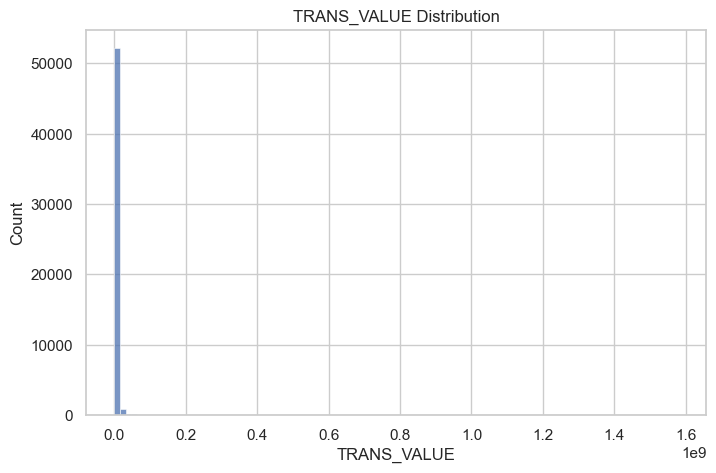

In [27]:
plt.figure(figsize=(8,5))
sns.histplot(df["TRANS_VALUE"], bins=100)
plt.title("TRANS_VALUE Distribution")
plt.show()


as the dataset is heavily right skewed, we do log transform on the transactions

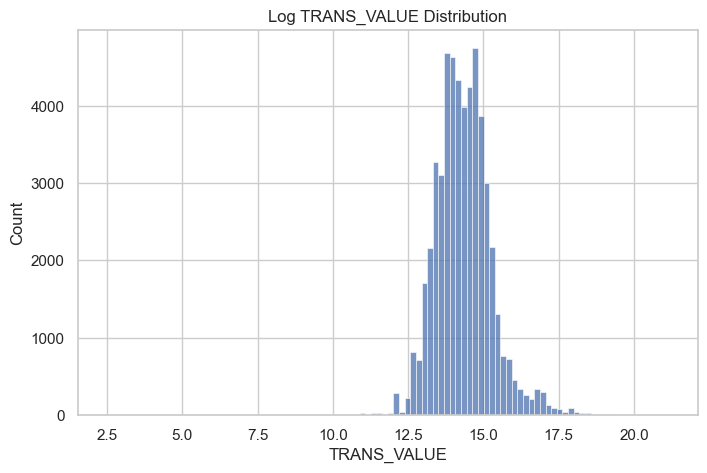

In [28]:
plt.figure(figsize=(8,5))
sns.histplot(np.log1p(df["TRANS_VALUE"]), bins=100)
plt.title("Log TRANS_VALUE Distribution")
plt.show()


In [29]:
### Let's analyse Price trends by property type

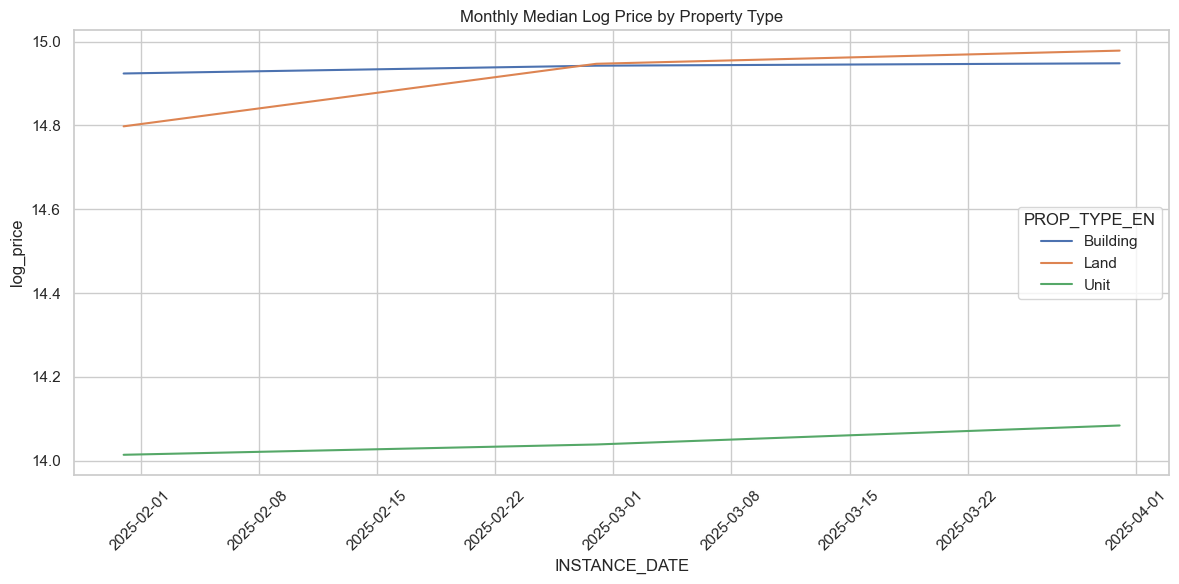

In [30]:
df["log_price"] = np.log1p(df["TRANS_VALUE"])

type_trend = (
    df.set_index("INSTANCE_DATE")
      .groupby("PROP_TYPE_EN")["log_price"]
      .resample("ME")
      .median()
      .reset_index()
)

plt.figure(figsize=(12,6))
sns.lineplot(
    data=type_trend,
    x="INSTANCE_DATE",
    y="log_price",
    hue="PROP_TYPE_EN"
)

plt.xticks(rotation=45)
plt.title("Monthly Median Log Price by Property Type")
plt.tight_layout()
plt.show()


Land shows the strongest upward trend, buildings remain stable, and units increase gradually. Property type also influences price.

### Let's analyse Price trends by property area
we group the areas by the median price for that area

In [31]:
area_median = df.groupby("AREA_EN")["TRANS_VALUE"].median().sort_values(ascending=False)
area_median.head(10)


AREA_EN
GRAND HILLS DUBAI             1.110000e+09
Al Safouh First               5.506750e+08
Mena Jabal Ali                5.190000e+08
Al Nahda First                1.050000e+08
Palm Jumeirah                 9.100250e+07
Al Eyas                       6.007425e+07
Muhaisanah Fourth             5.780000e+07
Ras Al Khor                   5.483871e+07
Al Qusais Industrial First    4.800000e+07
JUMEIRA BAY                   4.650000e+07
Name: TRANS_VALUE, dtype: float64

for analysis we do boxplot for 15 areas only

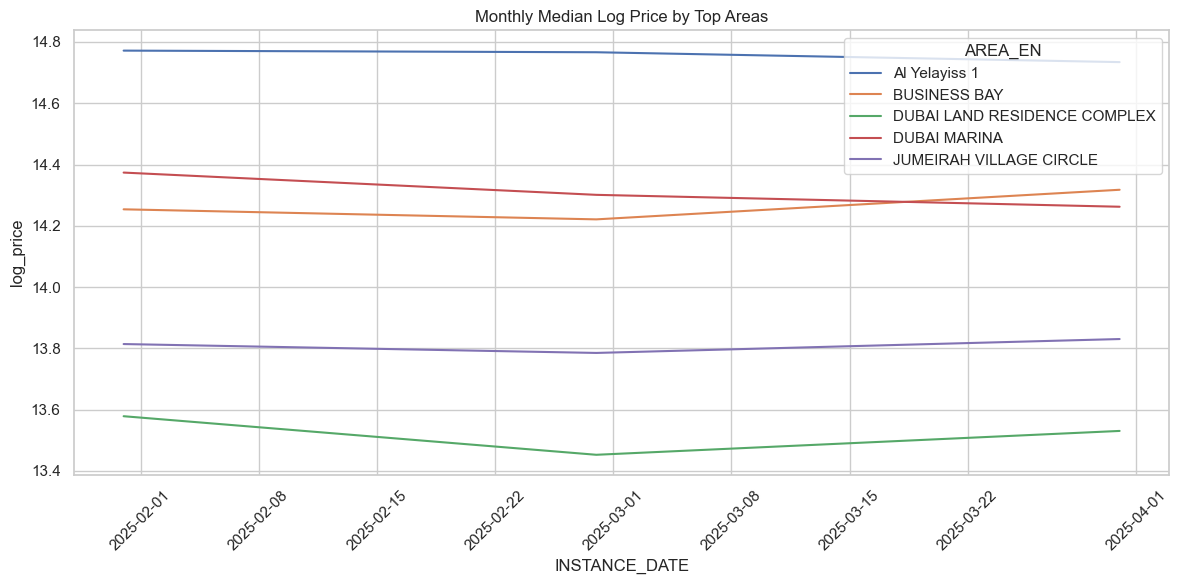

In [32]:
top_areas = df["AREA_EN"].value_counts().head(5).index

area_trend = (
    df[df["AREA_EN"].isin(top_areas)]
      .set_index("INSTANCE_DATE")
      .groupby("AREA_EN")["log_price"]
      .resample("ME")
      .median()
      .reset_index()
)

plt.figure(figsize=(12,6))
sns.lineplot(
    data=area_trend,
    x="INSTANCE_DATE",
    y="log_price",
    hue="AREA_EN"
)

plt.xticks(rotation=45)
plt.title("Monthly Median Log Price by Top Areas")
plt.tight_layout()
plt.show()


Top areas maintain almost consistent price levels, indicating consistent location-based pricing differences. Yes, area has major impact on prices

### Let's analyse Price trends by time


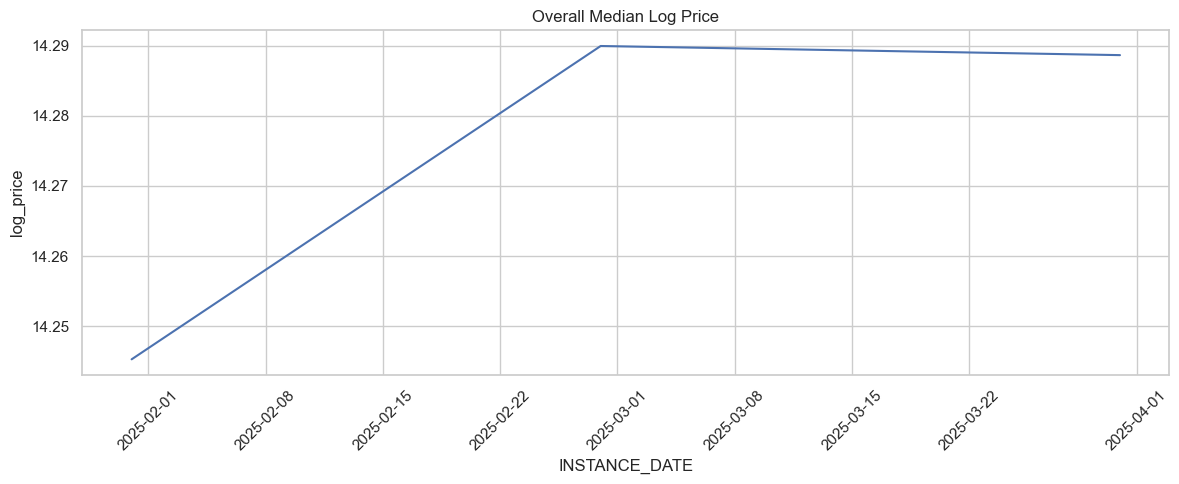

In [33]:
market_trend = (
    df.set_index("INSTANCE_DATE")["log_price"]
      .resample("ME")
      .median()
      .reset_index()
)

plt.figure(figsize=(12,5))
sns.lineplot(
    data=market_trend,
    x="INSTANCE_DATE",
    y="log_price"
)

plt.xticks(rotation=45)
plt.title("Overall Median Log Price")
plt.tight_layout()
plt.show()


The overall market shows a mild upward trend followed by stabilization, suggesting steady but modest appreciation.

Let's analyse impact of landmark features on log of property's prices, we will have a correlation matrix to determine each factor's impact on log prices.
we will frist encode metro, mall, landmark values and proceed with the impact 

In [34]:
# Metro encoding, high cardinality
# Keep top 20 frequent stations
top_metro = df["NEAREST_METRO_EN"].value_counts().head(20).index
df["NEAREST_METRO_EN"] = df["NEAREST_METRO_EN"].where(
    df["NEAREST_METRO_EN"].isin(top_metro), "Other"
)
metro_mean = df.groupby("NEAREST_METRO_EN")["log_price"].mean()
df["METRO_TE"] = df["NEAREST_METRO_EN"].map(
    metro_mean
)

# Mall encoding, high cardinality
# Keep top 20 frequent Mall
top_mall = df["NEAREST_MALL_EN"].value_counts().head(20).index
df["NEAREST_MALL_EN"] = df["NEAREST_MALL_EN"].where(
    df["NEAREST_MALL_EN"].isin(top_mall), "Other"
)
mall_mean = df.groupby("NEAREST_MALL_EN")["log_price"].mean()
df["MALL_TE"] = df["NEAREST_MALL_EN"].map(
    mall_mean
)

# Landmark encoding, high cardinality 
# Keep top 20 frequent Landmark
top_landmark = df["NEAREST_LANDMARK_EN"].value_counts().head(20).index
df["NEAREST_LANDMARK_EN"] = df["NEAREST_LANDMARK_EN"].where(
    df["NEAREST_LANDMARK_EN"].isin(top_landmark), "Other"
)
landmark_mean = df.groupby("NEAREST_LANDMARK_EN")["log_price"].mean()
df["LANDMARK_TE"] = df["NEAREST_LANDMARK_EN"].map(
    landmark_mean
)

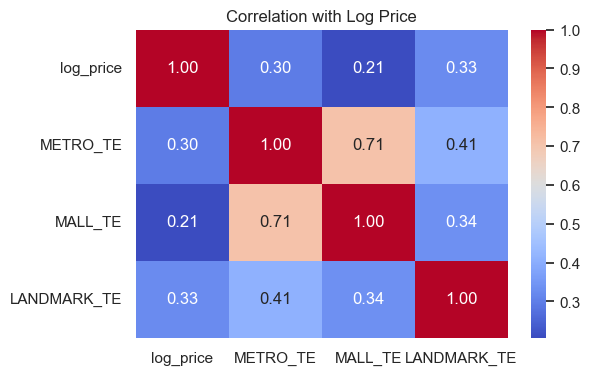

In [35]:
corr = df[["log_price", "METRO_TE", "MALL_TE", "LANDMARK_TE"]].corr()

plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation with Log Price")
plt.show()


landmark proximity (0.33) shows the strongest correlation with price among location features.

metro (0.30) has moderate influence.

mall (0.21) has weaker influence.

metro and mall encodings are strongly correlated (0.71), we can say that area that has metro will most likely have a mall.

offplan vs Ready

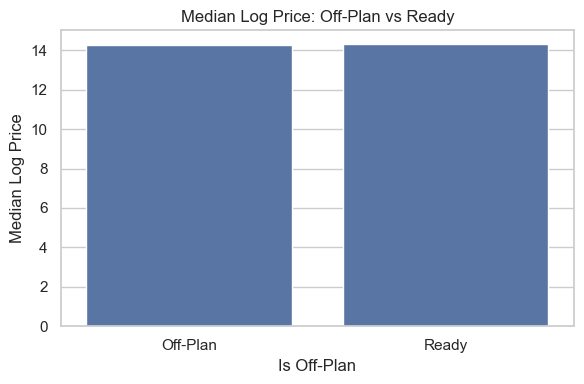

In [36]:
offplan_plot = (
    df.assign(log_price=np.log1p(df["TRANS_VALUE"]))
      .groupby("IS_OFFPLAN_EN")["log_price"]
      .median()
      .reset_index()
)

plt.figure(figsize=(6,4))
sns.barplot(
    data=offplan_plot,
    x="IS_OFFPLAN_EN",
    y="log_price"
)

plt.title("Median Log Price: Off-Plan vs Ready")
plt.xlabel("Is Off-Plan")
plt.ylabel("Median Log Price")
plt.tight_layout()
plt.show()


Median prices are almost identical, indicating construction status has not much impact on pricing.

Freehold vs Leasehold

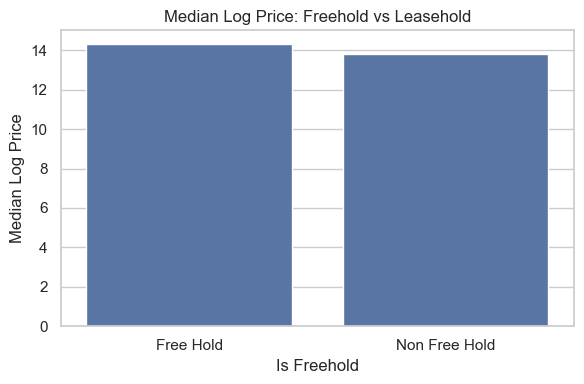

In [37]:
freehold_plot = (
    df.assign(log_price=np.log1p(df["TRANS_VALUE"]))
      .groupby("IS_FREE_HOLD_EN")["log_price"]
      .median()
      .reset_index()
)

plt.figure(figsize=(6,4))
sns.barplot(
    data=freehold_plot,
    x="IS_FREE_HOLD_EN",
    y="log_price"
)

plt.title("Median Log Price: Freehold vs Leasehold")
plt.xlabel("Is Freehold")
plt.ylabel("Median Log Price")
plt.tight_layout()
plt.show()


Freehold properties show a clear pricing difference over leasehold, suggesting ownership rights impact transaction value.

we don't derive price per sqm, becuase we would be using actual Y values derivatives in X and that would highly influence the final result so we skip creating the feature "price per sqm"

# More Feature Engineering

In [38]:
#log transfornations of TRANS_VALUE
df["log_price"] = np.log1p(df["TRANS_VALUE"])


#time featres
df["INSTANCE_DATE"] = pd.to_datetime(df["INSTANCE_DATE"])
df["year"] = df["INSTANCE_DATE"].dt.year
df["month"] = df["INSTANCE_DATE"].dt.month


#drop unncecessay cols
df = df.drop(columns=[
    "TRANSACTION_NUMBER",
    "GROUP_EN",
    "PROCEDURE_EN"
])

#Encoding type: One-Hot
low_card_cols = [
    "IS_OFFPLAN_EN",
    "IS_FREE_HOLD_EN",
    "USAGE_EN",
    "PROP_TYPE_EN",
    "ROOM_TYPE"
]
df = pd.get_dummies(df, columns=low_card_cols, drop_first=True)


#Area encoding-numeric
area_mean = df.groupby("AREA_EN")["log_price"].mean()
df["AREA_TE"] = df["AREA_EN"].map(
    area_mean
)

# Project encoding (high cardinality)
# Keep top 30 most frequent
top_projects = df["PROJECT_EN"].value_counts().head(30).index
project_mean = df.groupby("PROJECT_EN")["log_price"].mean()
global_mean = df["log_price"].mean()
df["PROJECT_EN"] = df["PROJECT_EN"].where(
    df["PROJECT_EN"].isin(top_projects), "Other"
)
df["PROJECT_TE"] = df["PROJECT_EN"].map(
    project_mean
).fillna(global_mean)



# sort chrnonlogically
df = df.sort_values("INSTANCE_DATE")


#drop raw cols
df = df.drop(columns=[
    "AREA_EN",
    "PROJECT_EN",
    "NEAREST_METRO_EN",
    "NEAREST_MALL_EN",
    "NEAREST_LANDMARK_EN",
    "PROP_SB_TYPE_EN",
    "ROOMS_EN",
    "TRANS_VALUE",
    "INSTANCE_DATE"
])


#train test split chronological
split_index = int(len(df) * 0.8)

train = df.iloc[:split_index]
test = df.iloc[split_index:]

X_train = train.drop(columns=["log_price"])
y_train = train["log_price"]

X_test = test.drop(columns=["log_price"])
y_test = test["log_price"]





# Model developement

Let's start with the very basic Linear regression as our baseline model. Although Linear regression is not suited for this problem as clearly we saw in the EDA the relationship was not largely linear but it's always better to start with Linear regression as a baseline model.
As done above, we will be working with the assumption that unknkown or new fields are replaced by global averages: If the model sees a new area it hasn’t seen before, it simply treats it as an average area and still makes a prediction instead of failing.

In [39]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
from lightgbm import LGBMRegressor
lr = LinearRegression()
lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

print("Linear Regression Performance:")
print("MAE (log scale):", mean_absolute_error(y_test, lr_pred))
print("R2:", r2_score(y_test, lr_pred))

Linear Regression Performance:
MAE (log scale): 0.3765927791175619
R2: 0.5999760812091794


In [40]:
X_train.isnull().sum().sort_values(ascending=False)


PROCEDURE_AREA                   0
ACTUAL_AREA                      0
TOTAL_BUYER                      0
TOTAL_SELLER                     0
PARKING                          0
parking_missing                  0
BEDROOMS                         0
METRO_TE                         0
MALL_TE                          0
LANDMARK_TE                      0
year                             0
month                            0
IS_OFFPLAN_EN_Ready              0
IS_FREE_HOLD_EN_Non Free Hold    0
USAGE_EN_Residential             0
PROP_TYPE_EN_Land                0
PROP_TYPE_EN_Unit                0
ROOM_TYPE_Office                 0
ROOM_TYPE_PENTHOUSE              0
ROOM_TYPE_Residential            0
ROOM_TYPE_Shop                   0
AREA_TE                          0
PROJECT_TE                       0
dtype: int64

In [41]:

model = LGBMRegressor()
model.fit(X_train, y_train)
pred = model.predict(X_test)

print("MAE (log scale):", mean_absolute_error(y_test, pred))
print("R2:", r2_score(y_test, pred))


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002428 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 946
[LightGBM] [Info] Number of data points in the train set: 42784, number of used features: 22
[LightGBM] [Info] Start training from score 14.321106
MAE (log scale): 0.20184709011080454
R2: 0.8627153558473062


In [42]:
real_pred = np.expm1(pred)
real_y = np.expm1(y_test)

print("MAE (real price):", mean_absolute_error(real_y, real_pred))


MAE (real price): 1127154.7173191395


## Let's see the important features that contributed the most

In [43]:

importance = pd.Series(
    model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print(importance.head(15))


AREA_TE                          807
PROCEDURE_AREA                   475
ACTUAL_AREA                      278
LANDMARK_TE                      254
METRO_TE                         207
PROJECT_TE                       185
MALL_TE                          132
BEDROOMS                         117
TOTAL_BUYER                      111
IS_FREE_HOLD_EN_Non Free Hold     73
IS_OFFPLAN_EN_Ready               67
month                             57
USAGE_EN_Residential              52
PARKING                           46
PROP_TYPE_EN_Unit                 43
dtype: int32


Feature importance shows that location (AREA_TE) is the major driver of price, followed by property size (ACTUAL_AREA, PROCEDURE_AREA) and proximity features (landmark, metro, project). properties like bedrooms and ownership type have moderate impact.

## Hyperparam tuning

In [44]:
lrs = [0.2, 0.1, 0.05, 0.01]

results_lr = []

for lr in lrs:
    model = LGBMRegressor(
        n_estimators=500,
        learning_rate=lr,
        random_state=42
    )
    
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    
    results_lr.append({
        "learning_rate": lr,
        "MAE_log": mean_absolute_error(y_test, pred),
        "R2": r2_score(y_test, pred)
    })

pd.DataFrame(results_lr)


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001904 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 946
[LightGBM] [Info] Number of data points in the train set: 42784, number of used features: 22
[LightGBM] [Info] Start training from score 14.321106
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002242 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 946
[LightGBM] [Info] Number of data points in the train set: 42784, number of used features: 22
[LightGBM] [Info] Start training from score 14.321106
[LightGBM] [Warning] Found w

,learning_rate,MAE_log,R2
0,0.20,0.183293,0.856806
1,0.10,0.184282,0.861132
2,0.05,0.188604,0.866507
3,0.01,0.218357,0.855926


0.05 as LR gives the best R2

In [45]:
leaves = [15, 31, 64, 128]

results_leaves = []

for leaves_num in leaves:
    model = LGBMRegressor(
        n_estimators=500,
        learning_rate=0.05,
        num_leaves=leaves_num,
        random_state=42
    )
    
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    
    results_leaves.append({
        "num_leaves": leaves_num,
        "MAE_log": mean_absolute_error(y_test, pred),
        "R2": r2_score(y_test, pred)
    })

pd.DataFrame(results_leaves)


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002578 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 946
[LightGBM] [Info] Number of data points in the train set: 42784, number of used features: 22
[LightGBM] [Info] Start training from score 14.321106
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002751 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 946
[LightGBM] [Info] Number of data points in the train set: 42784, number of used features: 22
[LightGBM] [Info] Start training from score 14.321106
[LightGBM] [Warning] Found w

,num_leaves,MAE_log,R2
0,15,0.198997,0.864560
1,31,0.188604,0.866507
2,64,0.184285,0.862714
3,128,0.182569,0.857532


number of leaves as 31 has the best bias-variance tradeoff

so final bgm model with the given hyperparams:

In [46]:
final_model = LGBMRegressor(
    n_estimators=500,      # more trees for smoother learning
    learning_rate=0.05,    # slightly better generalization
    num_leaves=31,         # optimal tree complexity
    max_depth=-1,          # let leaves control depth
    random_state=42
)

final_model.fit(X_train, y_train)

final_pred = final_model.predict(X_test)

from sklearn.metrics import mean_absolute_error, r2_score

print("Final Model Performance:")
print("MAE (log scale):", mean_absolute_error(y_test, final_pred))
print("R2:", r2_score(y_test, final_pred))

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001853 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 946
[LightGBM] [Info] Number of data points in the train set: 42784, number of used features: 22
[LightGBM] [Info] Start training from score 14.321106
Final Model Performance:
MAE (log scale): 0.18860441808938264
R2: 0.866506588356716


In [47]:
y_test_real = np.expm1(y_test)
pred_real = np.expm1(final_pred)

mape = np.mean(np.abs((y_test_real - pred_real) / y_test_real)) * 100

print("MAPE (%):", mape)

MAPE (%): 21.649557178230527


On average, predictions are off by 21.6% from actual property price

In [48]:
results_df = pd.DataFrame({
    "Actual": y_test_real,
    "Predicted": pred_real
})

# Absolute error
results_df["abs_error"] = np.abs(results_df["Actual"] - results_df["Predicted"])

# Percentage error
results_df["pct_error"] = (
    np.abs(results_df["Actual"] - results_df["Predicted"]) 
    / results_df["Actual"]
) * 100

In [49]:
worst_cases = results_df.sort_values("abs_error", ascending=False).head(10)
worst_indices = worst_cases.index
df_original.loc[worst_indices]


,TRANSACTION_NUMBER,INSTANCE_DATE,GROUP_EN,PROCEDURE_EN,IS_OFFPLAN_EN,IS_FREE_HOLD_EN,USAGE_EN,AREA_EN,PROP_TYPE_EN,PROP_SB_TYPE_EN,TRANS_VALUE,PROCEDURE_AREA,ACTUAL_AREA,ROOMS_EN,PARKING,NEAREST_METRO_EN,NEAREST_MALL_EN,NEAREST_LANDMARK_EN,TOTAL_BUYER,TOTAL_SELLER,MASTER_PROJECT_EN,PROJECT_EN
34199,11-9325-2025,2025-03-06 13:09:34,Sales,Sale,Ready,Free Hold,Residential,GRAND HILLS DUBAI,Land,NaN,1.110000e+09,1715752.11,1715752.11,NaN,NaN,NaN,NaN,NaN,1,1,NaN,NaN
23992,11-10796-2025,2025-03-17 12:27:39,Sales,Sale,Ready,Free Hold,Residential,Al Safouh First,Land,Residential,1.100000e+09,86607.43,86607.43,NaN,NaN,Sharaf Dg Metro Station,Mall of the Emirates,Burj Al Arab,1,1,NaN,NaN
43189,190-604-2025,2025-03-17 10:06:19,Mortgage,Delayed Mortgage,Ready,Free Hold,Residential,DUBAI WATER CANAL,Land,NaN,7.200000e+08,14634.18,14634.18,NaN,NaN,Business Bay Metro Station,Dubai Mall,Burj Khalifa,0,0,NaN,NaN
42516,14-348-2025,2025-03-12 08:07:31,Mortgage,Modify Mortgage,Ready,Free Hold,Commercial,TECOM SITE A,Land,Commercial,6.200000e+08,86281.25,86281.25,NaN,NaN,Al Sufouh,Mall of the Emirates,Burj Al Arab,0,0,NaN,NaN
42499,14-328-2025,2025-03-10 13:26:15,Mortgage,Modify Mortgage,Ready,Non Free Hold,Commercial,BUSINESS BAY,Land,Commercial,3.000000e+08,3717.70,3717.70,NaN,NaN,Business Bay Metro Station,Dubai Mall,Burj Khalifa,0,0,NaN,NaN
25115,11-11845-2025,2025-03-21 10:29:06,Sales,Sale,Ready,Free Hold,Commercial,Business Bay,Land,Commercial,1.800000e+08,1858.06,1858.06,NaN,NaN,NaN,NaN,NaN,1,1,NaN,NaN
52513,9-1524-2025,2025-03-20 12:54:21,Gifts,Grant,Ready,Free Hold,Residential,FALCON CITY OF WONDERS,Land,Residential,2.128847e+08,38861.76,38861.76,NaN,NaN,NaN,NaN,IMG World Adventures,0,0,NaN,BELGRAVIA GARDENS
48710,41-8504-2025,2025-03-11 12:34:15,Sales,Delayed Sell,Ready,Free Hold,Residential,DUBAI HEALTHCARE CITY - PHASE 2,Land,Hospital,1.563706e+08,16456.14,16456.14,NaN,NaN,Creek Metro Station,Dubai Mall,Downtown Dubai,1,1,NaN,NaN
42548,14-382-2025,2025-03-17 11:15:32,Mortgage,Modify Mortgage,Ready,Free Hold,Commercial,Palm Jumeirah,Land,Commercial,2.215000e+08,5609.22,5609.22,NaN,NaN,NaN,NaN,NaN,0,0,NaN,NaN
42522,14-354-2025,2025-03-12 08:08:26,Mortgage,Modify Mortgage,Ready,Free Hold,Commercial,AL FURJAN,Land,Commercial,1.500000e+08,2158.60,2158.60,NaN,NaN,Ibn Battuta Metro Station,Ibn-e-Battuta Mall,Expo 2020 Site,0,0,NaN,NaN


as we can see the top 10 properties with worse predictions, we can clearly see those proprties have very high prices, they lie in the outlier range as till 95th percentile, 8.000000e+06 is the price range from the distribution provided in the beginning

95%   --------------              8.000000e+06 



Important feature visualisation

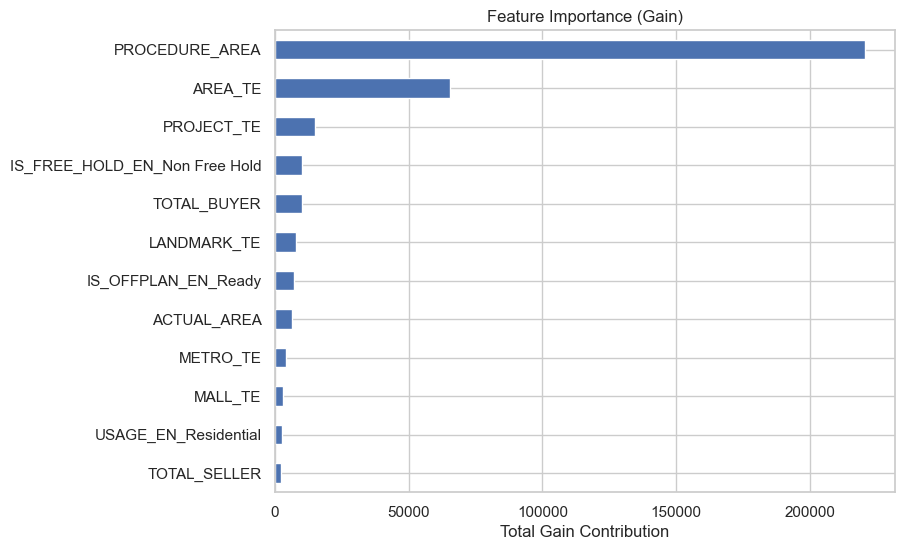

In [50]:
importance = pd.Series(
    final_model.booster_.feature_importance(importance_type="gain"),
    index=X_train.columns
).sort_values(ascending=False)

plt.figure(figsize=(8,6))
importance.head(12).plot(kind="barh")
plt.gca().invert_yaxis()
plt.title("Feature Importance (Gain)")
plt.xlabel("Total Gain Contribution")
plt.show()


D:\projectLite\real_estate_val\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


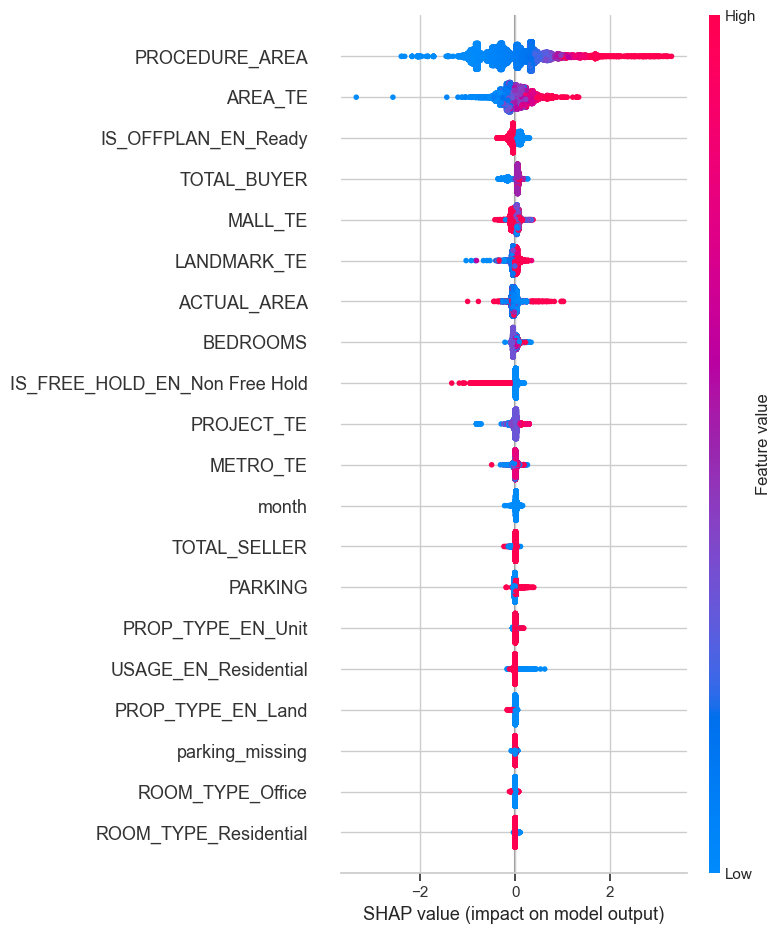

In [51]:
import shap

explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test)


The model mostly looks at property size and area to decide the price, bigger homes in better areas mean higher price.

Metro, mall, and landmarks matter a little, but not as much.

Month and small details don’t change the price much.

## Further Analysis

Area is the biggest factor, Properties with more areas are priced higher.

Nearby metro, mall, or landmarks help, Good location adds value, but not as much as area and size.

Freehold and off-plan matter a bit, they affect price, but not heavily.

Very expensive homes are harder to predict

# Save model

In [52]:
import joblib
joblib.dump(final_model, "../models/trained_model.pkl")


['../models/trained_model.pkl']

# save encoing

In [53]:
joblib.dump(area_mean, "../encodings/area_mean.pkl")
joblib.dump(project_mean, "../encodings/project_mean.pkl")
joblib.dump(metro_mean, "../encodings/metro_mean.pkl")
joblib.dump(mall_mean, "../encodings/mall_mean.pkl")
joblib.dump(landmark_mean, "../encodings/landmark_mean.pkl")

['../encodings/landmark_mean.pkl']